In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score

from xgboost import XGBRegressor, plot_importance
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
import pandas as pd

df = pd.read_excel('/content/drive/MyDrive/ML solarcell dataset/concatenated_all_final.xlsx')

df.head(5)

,L1 Thickness,L1 Bg,L1 Ea,L1 Dp,L1 Nc,L1 Nv,L1 Ue,L1 Uh,L1 Na,L1 dd,...,L2 Nv,L2 Ue,L2 Uh,L2 Na,L2 dd,Voc,Jsc,FF,PCE,Structure
0,0.1,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.971704,37.583326,87.4922,31.9520,Structure_1
1,0.2,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.971972,37.923123,87.5007,32.2529,Structure_1
2,0.3,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.972158,38.144859,87.4986,32.4469,Structure_1
3,0.4,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.972395,38.294786,87.3901,32.5420,Structure_1
4,0.5,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,1.800000e+19,100,25,5.000000e+19,100000000000000,0.972767,38.399561,87.0872,32.5304,Structure_1


In [77]:
from sklearn.preprocessing import LabelEncoder

# Replace 'Structure_x' with just x
df["Structure"] = df["Structure"].str.replace("Structure_", "").astype(int)

In [78]:
bsf_map = {
    1: 'MoS2', 2: 'MoS2', 3: 'WSe2', 4: 'MoS2', 5: 'WSe2', 6: 'MoS2', 7: 'CGS', 8: 'MoS2',
    9: 'WSe2', 10: 'MoS2', 11: 'CGS', 12: 'WSe2', 13: 'MoS2', 14: 'MoS2', 15: 'CGS',
    16: 'WSe2', 17: 'WSe2', 18: 'MoS2', 19: 'CGS', 20: 'WSe2', 21: 'WSe2',
    22: 'WSe2', 23: 'CGS', 24: 'WSe2',
}

# Create new column using map
df["BSF"] = df["Structure"].map(bsf_map)

bsf_map = {
    'MoS2': 1,
    'WSe2': 2,
    'CGS': 3,
}

# Create new column using map
df["BSF"] = df["BSF"].map(bsf_map)

In [79]:
df.head()

,L1 Thickness,L1 Bg,L1 Ea,L1 Dp,L1 Nc,L1 Nv,L1 Ue,L1 Uh,L1 Na,L1 dd,...,L2 Ue,L2 Uh,L2 Na,L2 dd,Voc,Jsc,FF,PCE,Structure,BSF
0,0.1,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,100,25,5.000000e+19,100000000000000,0.971704,37.583326,87.4922,31.9520,1,1
1,0.2,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,100,25,5.000000e+19,100000000000000,0.971972,37.923123,87.5007,32.2529,1,1
2,0.3,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,100,25,5.000000e+19,100000000000000,0.972158,38.144859,87.4986,32.4469,1,1
3,0.4,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,100,25,5.000000e+19,100000000000000,0.972395,38.294786,87.3901,32.5420,1,1
4,0.5,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,100000000000000,...,100,25,5.000000e+19,100000000000000,0.972767,38.399561,87.0872,32.5304,1,1


In [80]:
df.describe()

,L1 Thickness,L1 Bg,L1 Ea,L1 Dp,L1 Nc,L1 Nv,L1 Ue,L1 Uh,L1 Na,L1 dd,...,L2 Ue,L2 Uh,L2 Na,L2 dd,Voc,Jsc,FF,PCE,Structure,BSF
count,16790.000000,16790.000000,16790.000000,16790.000000,1.679000e+04,1.679000e+04,16790.000000,16790.000000,1.679000e+04,1.679000e+04,...,16790.000000,16790.000000,1.679000e+04,1.679000e+04,16790.000000,16790.000000,16790.000000,16790.000000,16790.000000,16790.000000
mean,3.007433,1.401331,4.262519,12.645408,5.655086e+18,1.736610e+19,330.229801,110.002824,8.381587e+17,1.033385e+14,...,1018.513401,25.298035,4.319529e+19,1.193201e+14,0.994534,37.207171,82.330058,30.274492,12.357594,1.789756
std,5.261317,0.175999,0.192034,2.773158,1.019237e+19,2.494934e+19,456.961158,171.066425,5.584472e+18,3.850195e+14,...,1202.437309,5.517113,6.022537e+19,3.824673e+14,0.143752,7.213629,6.459050,6.761151,6.842070,0.723895
min,0.100000,0.900000,3.800000,1.000000,5.000000e+15,5.000000e+15,10.000000,1.000000,1.000000e+14,1.000000e+11,...,10.000000,1.000000,1.000000e+15,1.000000e+12,0.476734,0.005364,22.475700,0.005200,1.000000,1.000000
25%,0.700000,1.200000,4.100000,10.500000,1.180000e+18,4.570000e+18,100.000000,25.000000,1.000000e+16,1.000000e+14,...,100.000000,20.000000,1.000000e+18,1.000000e+14,0.911674,34.735479,79.623800,25.892425,6.000000,1.000000
50%,0.700000,1.500000,4.280000,12.500000,1.200000e+18,5.200000e+18,130.000000,50.000000,1.000000e+16,1.000000e+14,...,700.000000,25.000000,5.000000e+19,1.000000e+14,0.999238,38.514235,83.437550,31.571900,12.000000,2.000000
75%,0.800000,1.500000,4.400000,14.800000,2.200000e+18,1.800000e+19,320.000000,56.700000,1.000000e+16,1.000000e+14,...,3000.000000,30.000000,5.000000e+19,1.000000e+14,1.097389,41.675635,86.670900,35.865650,18.000000,2.000000
max,19.000000,2.350000,5.200000,45.000000,1.000000e+20,1.000000e+20,1350.000000,500.000000,5.000000e+19,1.000000e+16,...,3000.000000,90.000000,5.000000e+20,1.000000e+16,1.539987,57.958243,91.135200,43.931400,24.000000,3.000000


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16790 entries, 0 to 16789
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   L1 Thickness  16790 non-null  float64
 1   L1 Bg         16790 non-null  float64
 2   L1 Ea         16790 non-null  float64
 3   L1 Dp         16790 non-null  float64
 4   L1 Nc         16790 non-null  float64
 5   L1 Nv         16790 non-null  float64
 6   L1 Ue         16790 non-null  float64
 7   L1 Uh         16790 non-null  float64
 8   L1 Na         16790 non-null  float64
 9   L1 dd         16790 non-null  int64  
 10  L2 Thickness  16790 non-null  float64
 11  L2 Bg         16790 non-null  float64
 12  L2 Ea         16790 non-null  float64
 13  L2 Dp         16790 non-null  float64
 14  L2 Nc         16790 non-null  float64
 15  L2 Nv         16790 non-null  float64
 16  L2 Ue         16790 non-null  int64  
 17  L2 Uh         16790 non-null  int64  
 18  L2 Na         16790 non-nu

In [82]:
for col in df.columns:
  if col not in  ['Structure', 'BSF']:
    df[col] = df[col].astype('float64')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16790 entries, 0 to 16789
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   L1 Thickness  16790 non-null  float64
 1   L1 Bg         16790 non-null  float64
 2   L1 Ea         16790 non-null  float64
 3   L1 Dp         16790 non-null  float64
 4   L1 Nc         16790 non-null  float64
 5   L1 Nv         16790 non-null  float64
 6   L1 Ue         16790 non-null  float64
 7   L1 Uh         16790 non-null  float64
 8   L1 Na         16790 non-null  float64
 9   L1 dd         16790 non-null  float64
 10  L2 Thickness  16790 non-null  float64
 11  L2 Bg         16790 non-null  float64
 12  L2 Ea         16790 non-null  float64
 13  L2 Dp         16790 non-null  float64
 14  L2 Nc         16790 non-null  float64
 15  L2 Nv         16790 non-null  float64
 16  L2 Ue         16790 non-null  float64
 17  L2 Uh         16790 non-null  float64
 18  L2 Na         16790 non-nu

In [83]:
# Finding max value
max = df.PCE.max()
max

43.9314

In [84]:
df['FF'] = df['FF'] / 100

In [ ]:
# df[df["FF"] < .60]

In [ ]:
# df = df[df["FF"] >= .60]

In [ ]:
# df = df[df.PCE != 0]

In [85]:
df.head()

,L1 Thickness,L1 Bg,L1 Ea,L1 Dp,L1 Nc,L1 Nv,L1 Ue,L1 Uh,L1 Na,L1 dd,...,L2 Ue,L2 Uh,L2 Na,L2 dd,Voc,Jsc,FF,PCE,Structure,BSF
0,0.1,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,100.0,25.0,5.000000e+19,1.000000e+14,0.971704,37.583326,0.874922,31.9520,1,1
1,0.2,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,100.0,25.0,5.000000e+19,1.000000e+14,0.971972,37.923123,0.875007,32.2529,1,1
2,0.3,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,100.0,25.0,5.000000e+19,1.000000e+14,0.972158,38.144859,0.874986,32.4469,1,1
3,0.4,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,100.0,25.0,5.000000e+19,1.000000e+14,0.972395,38.294786,0.873901,32.5420,1,1
4,0.5,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,1.000000e+16,1.000000e+14,...,100.0,25.0,5.000000e+19,1.000000e+14,0.972767,38.399561,0.870872,32.5304,1,1


In [86]:
df['L1 Bg + L1 Ea'] = df['L1 Bg'] + df['L1 Ea']
df['L2 Bg + L2 Ea'] = df['L2 Bg'] + df['L2 Ea']

df['CB offset'] = df['L1 Ea'] - df['L2 Ea']
df['VB offset'] = df['L1 Bg + L1 Ea'] - df['L2 Bg + L2 Ea']

df.drop(columns=["L1 Bg + L1 Ea", "L2 Bg + L2 Ea"], inplace=True)

# **Train Test Split**

In [87]:
# Define y and X structures
y_structures = [2, 7, 20 ]

# Create X and y datasets
y_data = df[df["Structure"].isin(y_structures)]
X_data = df[~df["Structure"].isin(y_structures)]

# Drop "Structure" column from features
X = X_data.drop(columns=["Structure"])
y = y_data.drop(columns=["Structure"])


X_train = X.drop(columns=["Voc", "Jsc", "FF", "PCE"])
y_train = X[["Voc", "Jsc", "FF", "PCE"]]

X_test = y.drop(columns=["Voc", "Jsc", "FF", "PCE"])
y_test = y[["Voc", "Jsc", "FF", "PCE"]]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (14661, 23)
X_test shape: (2129, 23)
y_train shape: (14661, 4)
y_test shape: (2129, 4)


In [ ]:
# df.drop(columns=["Structure"], inplace=True)

In [ ]:
# # Features and target variables
# X = df.drop(['Voc', 'Jsc', 'FF', 'PCE'], axis = 1)

# y = df[['Voc', 'Jsc', 'FF', 'PCE']]

# # Split the dataset (90% training, 10% testing)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state = 42)

In [31]:
y_test

,Voc,Jsc,FF,PCE
557,1.186446,33.371419,0.895142,35.4417
558,1.186639,33.876963,0.894780,35.9699
559,1.186642,34.201625,0.892644,36.2281
560,1.186562,34.418133,0.889276,36.3173
561,1.186431,34.567294,0.885870,36.3310
...,...,...,...,...
14059,1.075484,38.520707,0.884610,36.6480
14060,1.016655,38.440020,0.880056,34.3928
14061,1.074907,38.520453,0.883909,36.5991
14062,1.016496,38.425498,0.879913,34.3689


# <font color="lightgreen"> **Random Forest Regressor (RF)**

In [60]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Initialize RF model with your best hyperparameters
best_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
)

# Train model
best_rf.fit(X_train, y_train)

# Predictions
rf_y_pred = best_rf.predict(X_test)

# Convert predictions to DataFrame
rf_y_pred_df = pd.DataFrame(rf_y_pred, columns=['Voc', 'Jsc', 'FF', 'PCE'])

# Evaluation
rf_mse = mean_squared_error(y_test, rf_y_pred_df, multioutput='raw_values')
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_y_pred_df, multioutput='raw_values')
rf_r2 = r2_score(y_test, rf_y_pred_df, multioutput='raw_values')

# Print metrics
metrics_df_RF = pd.DataFrame( {'MSE': rf_mse, 'RMSE': rf_rmse, 'MAE': rf_mae, 'R2 Score': rf_r2 }, index=['Voc', 'Jsc', 'FF', 'PCE'])

print("Random Forest Metrics:\n", metrics_df_RF)


Random Forest Metrics:
           MSE      RMSE       MAE  R2 Score
Voc  0.001812  0.042569  0.022438  0.928844
Jsc  3.785092  1.945531  0.837164  0.922233
FF   0.000689  0.026251  0.011768  0.875278
PCE  4.229056  2.056467  0.934128  0.920017


# <font color="lightgreen"> **Gradient Boosting Regressor (GBR)**

In [59]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Initialize GBR with your best hyperparameters
best_gbr = MultiOutputRegressor(
    GradientBoostingRegressor(
      learning_rate= 0.2, max_depth= 10, n_estimators= 200,
    )
)

# Train model
best_gbr.fit(X_train, y_train)

# Predictions
gbr_y_pred = best_gbr.predict(X_test)

# Convert predictions to DataFrame
gbr_y_pred_df = pd.DataFrame(gbr_y_pred, columns=['Voc', 'Jsc', 'FF', 'PCE'])

# Evaluation
gbr_mse = mean_squared_error(y_test, gbr_y_pred_df, multioutput='raw_values')
gbr_rmse = np.sqrt(gbr_mse)
gbr_mae = mean_absolute_error(y_test, gbr_y_pred_df, multioutput='raw_values')
gbr_r2 = r2_score(y_test, gbr_y_pred_df, multioutput='raw_values')

# Print metrics
metrics_df_GBR = pd.DataFrame({'MSE': gbr_mse,'RMSE': gbr_rmse,'MAE': gbr_mae,'R2 Score': gbr_r2}, index=['Voc', 'Jsc', 'FF', 'PCE'])

print("Gradient Boosting Metrics:\n", metrics_df_GBR)


Gradient Boosting Metrics:
           MSE      RMSE       MAE  R2 Score
Voc  0.001675  0.040926  0.016150  0.934229
Jsc  3.196207  1.787794  0.779256  0.934332
FF   0.000727  0.026954  0.012042  0.868506
PCE  2.044822  1.429973  0.805449  0.961327


# <font color="lightgreen"> **Linear regression**

In [57]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.fit_transform(X_test)

# scaler_y = StandardScaler()
# y_train_scaled = scaler_y.fit_transform(y_train)
# y_test_scaled = scaler_y.transform(y_test)

In [58]:
# Train the model
lr = LinearRegression()
lr.fit(x_train, y_train)

# Predictions
lr_y_pred = lr.predict(x_test)

# Convert predictions to DataFrame
lr_y_pred_df = pd.DataFrame(lr_y_pred, columns=['Voc', 'Jsc', 'FF', 'PCE'])

# Evaluation
lr_mse = mean_squared_error(y_test, lr_y_pred_df, multioutput='raw_values')
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, lr_y_pred_df, multioutput='raw_values')
lr_r2 = r2_score(y_test, lr_y_pred_df, multioutput='raw_values')

# Print metrics
metrics_df_lr = pd.DataFrame({'MSE': lr_mse, 'RMSE': lr_rmse, 'MAE': lr_mae, 'R2 Score': lr_r2},
                           index=['Voc', 'Jsc', 'FF', 'PCE'])
print(metrics_df_lr)

           MSE      RMSE       MAE  R2 Score
Voc   0.017582  0.132598  0.105496  0.309597
Jsc  29.625847  5.442963  3.593451  0.391318
FF    0.004709  0.068625  0.042969  0.147666
PCE  46.397967  6.811605  5.579052  0.122486


# <font color="lightgreen">**DT regressor**

In [56]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Initialize Decision Tree with your best hyperparameters
best_dt = DecisionTreeRegressor(
    max_depth= None, min_samples_leaf= 1, min_samples_split= 2
)

# Train model
best_dt.fit(X_train, y_train)

# Predictions
dt_y_pred = best_dt.predict(X_test)

# Convert predictions to DataFrame
dt_y_pred_df = pd.DataFrame(dt_y_pred, columns=['Voc', 'Jsc', 'FF', 'PCE'])

# Evaluation
mse = mean_squared_error(y_test, dt_y_pred_df, multioutput='raw_values')
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, dt_y_pred_df, multioutput='raw_values')
r2 = r2_score(y_test, dt_y_pred_df, multioutput='raw_values')

# Print metrics
metrics_df_DT = pd.DataFrame({
    'MSE': mse,
    'RMSE': rmse,
    'MAE': mae,
    'R2 Score': r2
}, index=['Voc', 'Jsc', 'FF', 'PCE'])

print("Decision Tree Metrics:\n", metrics_df_DT)


Decision Tree Metrics:
           MSE      RMSE       MAE  R2 Score
Voc  0.002509  0.050091  0.025977  0.901473
Jsc  5.282222  2.298309  0.980121  0.891473
FF   0.001212  0.034817  0.015910  0.780606
PCE  5.941353  2.437489  1.269324  0.887633


# <font color="lightgreen"> **XGB regressor**

In [88]:
# Initializing XGBoost Regressor
xgb_reg = XGBRegressor( learning_rate= 0.2, max_depth= 10, n_estimators= 200, subsample= 0.8, objective='reg:squarederror')

# Training the model
xgb_reg.fit(X_train, y_train)

# Predictions
y_pred_XGB = xgb_reg.predict(X_test)

# Convert predictions to DataFrame
y_pred_XGB_df = pd.DataFrame(y_pred_XGB, columns=['Voc', 'Jsc', 'FF', 'PCE'])

# Evaluation
mse = mean_squared_error(y_test, y_pred_XGB_df, multioutput='raw_values')
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_XGB_df, multioutput='raw_values')
r2 = r2_score(y_test, y_pred_XGB_df, multioutput='raw_values')

# Print metrics
metrics_df_XGB = pd.DataFrame({'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2},
                           index=['Voc', 'Jsc', 'FF', 'PCE'])
print(metrics_df_XGB)

          MSE      RMSE       MAE  R2 Score
Voc  0.000726  0.026941  0.012909  0.971499
Jsc  3.057493  1.748569  0.776111  0.937182
FF   0.000536  0.023156  0.011719  0.902953
PCE  1.650025  1.284533  0.761053  0.968793


# Creating DOCX for all model performance

In [89]:
import pandas as pd
import numpy as np

# === MAKE SURE all these DataFrames are already created ===
# metrics_df_lr, metrics_df_DT, metrics_df_RF, metrics_df_GBR, metrics_df_XGB

# 🧩 Dictionary of models
models = {
    'LR (Linear Regression)': metrics_df_lr,
    'DT (Decision Tree)': metrics_df_DT,
    'RF (Random Forest)': metrics_df_RF,
    'GBR (Gradient Boosting)': metrics_df_GBR,
    'XGBoost': metrics_df_XGB
}

# === Combine only test set results ===
rows = []
for model_name, df in models.items():
    rows.append({
        'Regression Type': model_name,
        'Evaluation Type': 'MAE',
        **df['MAE'].to_dict()
    })
    rows.append({
        'Regression Type': model_name,
        'Evaluation Type': 'MSE',
        **df['MSE'].to_dict()
    })
    rows.append({
        'Regression Type': model_name,
        'Evaluation Type': 'RMSE',
        **df['RMSE'].to_dict()
    })
    rows.append({
        'Regression Type': model_name,
        'Evaluation Type': 'R²',
        **df['R2 Score'].to_dict()
    })

# Convert to DataFrame
table_df = pd.DataFrame(rows)

# Reorder columns
table_df = table_df[['Regression Type', 'Evaluation Type', 'Voc', 'Jsc', 'FF', 'PCE']]

# Round numerical values
table_df[['Voc', 'Jsc', 'FF', 'PCE']] = table_df[['Voc', 'Jsc', 'FF', 'PCE']].applymap(lambda x: round(x, 4))

# === Display final formatted table ===
print("\nFinal Table (Test Set Only):\n")
print(table_df.to_string(index=False))

# === Export options ===

# Save as Excel
table_df.to_excel("Model_Performance_Table_TestSet.xlsx", index=False)

# Save as LaTeX (for paper)
latex_table = table_df.to_latex(index=False, caption="Property indicators of each algorithm (Test set).", label="tab:model_metrics_test", float_format="%.4f")
with open("Model_Performance_Table_TestSet.tex", "w") as f:
    f.write(latex_table)

print("\n✅ Table saved as 'Model_Performance_Table_TestSet.xlsx' and 'Model_Performance_Table_TestSet.tex'")



Final Table (Test Set Only):

        Regression Type Evaluation Type    Voc     Jsc     FF     PCE
 LR (Linear Regression)             MAE 0.1055  3.5935 0.0430  5.5791
 LR (Linear Regression)             MSE 0.0176 29.6258 0.0047 46.3980
 LR (Linear Regression)            RMSE 0.1326  5.4430 0.0686  6.8116
 LR (Linear Regression)              R² 0.3096  0.3913 0.1477  0.1225
     DT (Decision Tree)             MAE 0.0260  0.9801 0.0159  1.2693
     DT (Decision Tree)             MSE 0.0025  5.2822 0.0012  5.9414
     DT (Decision Tree)            RMSE 0.0501  2.2983 0.0348  2.4375
     DT (Decision Tree)              R² 0.9015  0.8915 0.7806  0.8876
     RF (Random Forest)             MAE 0.0224  0.8372 0.0118  0.9341
     RF (Random Forest)             MSE 0.0018  3.7851 0.0007  4.2291
     RF (Random Forest)            RMSE 0.0426  1.9455 0.0263  2.0565
     RF (Random Forest)              R² 0.9288  0.9222 0.8753  0.9200
GBR (Gradient Boosting)             MAE 0.0162  0.7793 0.01

/tmp/ipython-input-3772662301.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  table_df[['Voc', 'Jsc', 'FF', 'PCE']] = table_df[['Voc', 'Jsc', 'FF', 'PCE']].applymap(lambda x: round(x, 4))


In [90]:
!pip install python-docx

In [91]:
from docx import Document

# Create Word document
doc = Document()
doc.add_heading("Table: Property indicators of each algorithm (Test set)", level=2)

# Create table with same columns as DataFrame
table = doc.add_table(rows=1, cols=len(table_df.columns))
table.style = 'Light Grid'  # you can use other styles like 'Table Grid'

# Add header row
hdr_cells = table.rows[0].cells
for i, col_name in enumerate(table_df.columns):
    hdr_cells[i].text = str(col_name)

# Add data rows
for _, row in table_df.iterrows():
    row_cells = table.add_row().cells
    for i, val in enumerate(row):
        row_cells[i].text = str(round(val, 4)) if isinstance(val, (int, float)) else str(val)

# Save the file
doc.save("Model_Performance_Table_TestSet.docx")

print("\n✅ Word file saved as 'Model_Performance_Table_TestSet.docx'")



✅ Word file saved as 'Model_Performance_Table_TestSet.docx'


#  <font color="lightgreen"> **Testing Unknown pure Structures**

In [61]:
df_test = pd.read_excel('/content/drive/MyDrive/ML solarcell dataset/Predefined_structure_test.xlsx')
df_test.drop(columns=["Number"], inplace=True)
df_test["BSF"] = df_test["BSF"].map(bsf_map)
df_test.astype('float64')
df_test.FF = df_test.FF / 100

df_test['L1 Bg + L1 Ea'] = df_test['L1 Bg'] + df_test['L1 Ea']
df_test['L2 Bg + L2 Ea'] = df_test['L2 Bg'] + df_test['L2 Ea']
df_test['CB offset'] = df_test['L1 Ea'] - df_test['L2 Ea']
df_test['VB offset'] = df_test['L1 Bg + L1 Ea'] - df_test['L2 Bg + L2 Ea']

df_test.drop(columns=["L1 Bg + L1 Ea", "L2 Bg + L2 Ea"], inplace=True)


df_test.head(7)

,L1 Thickness,L1 Bg,L1 Ea,L1 Dp,L1 Nc,L1 Nv,L1 Ue,L1 Uh,L1 Na,L1 dd,...,L2 Uh,L2 Na,L2 dd,BSF,Voc,Jsc,FF,PCE,CB offset,VB offset
0,0.7,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,10000000000000000,100000000000000,...,25,5.000000e+19,100000000000000,1,0.973571,38.480775,0.865916,32.4405,0.20,0.60
1,0.7,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,10000000000000000,100000000000000,...,30,5.000000e+19,100000000000000,1,1.186083,34.748153,0.879348,36.2416,0.10,0.40
2,0.7,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,10000000000000000,100000000000000,...,25,1.000000e+17,100000000000000,2,0.687863,39.343061,0.764222,20.6819,0.49,0.92
3,0.7,1.5,4.5,14.8,2.200000e+18,1.800000e+19,100.0,50.0,10000000000000000,100000000000000,...,20,5.000000e+19,100000000000000,1,1.027789,38.513562,0.856874,33.9184,0.22,0.62
4,0.7,1.5,4.4,10.5,1.180000e+18,4.760000e+18,100.0,25.0,10000000000000000,100000000000000,...,25,5.000000e+19,100000000000000,2,0.989863,36.014638,0.810569,28.8964,0.10,0.50
5,0.7,1.5,4.4,10.5,1.180000e+18,4.760000e+18,100.0,25.0,10000000000000000,100000000000000,...,30,5.000000e+19,100000000000000,1,1.188633,34.746928,0.886144,36.5989,0.00,0.30
6,0.7,1.5,4.4,10.5,1.180000e+18,4.760000e+18,100.0,25.0,10000000000000000,100000000000000,...,25,1.000000e+17,100000000000000,3,0.795512,39.306637,0.768304,24.0240,0.39,0.82


In [62]:
y_test_str = df_test[['Voc', 'Jsc', 'FF', 'PCE']]
x_test_str = df_test.drop(columns=['Voc', 'Jsc', 'FF', 'PCE'])

# Predictions
y_pred = xgb_reg.predict(x_test_str)

# Convert predictions to DataFrame
y_pred = pd.DataFrame(y_pred, columns=['Voc', 'Jsc', 'FF', 'PCE'])

In [63]:
y_test_str.iloc[[1,6,19]]

,Voc,Jsc,FF,PCE
1,1.186083,34.748153,0.879348,36.2416
6,0.795512,39.306637,0.768304,24.0240
19,1.108161,38.475650,0.888423,37.8799


In [64]:
y_pred.iloc[[1,6,19]]

,Voc,Jsc,FF,PCE
1,1.189212,34.966957,0.873995,36.272629
6,0.797337,39.322441,0.766952,24.220875
19,1.100995,38.359482,0.881141,37.901855


# <font color="lightgreen">**Comparing Models according to PCE**

In [65]:
# Create a dictionary to store the PCE metrics for each model
pce_metrics = {
    'Decision Tree': metrics_df_DT.loc["PCE"],
    'Linear Regression': metrics_df_lr.loc["PCE"],
    'Gradient Boosting': metrics_df_GBR.loc["PCE"],
    'Random Forest': metrics_df_RF.loc["PCE"],
    'XGBoost': metrics_df_XGB.loc["PCE"]
}

# Create a DataFrame from the dictionary
comparison_df = pd.DataFrame(pce_metrics).T

comparison_df

,MSE,RMSE,MAE,R2 Score
Decision Tree,5.941353,2.437489,1.269324,0.887633
Linear Regression,46.397967,6.811605,5.579052,0.122486
Gradient Boosting,2.044822,1.429973,0.805449,0.961327
Random Forest,4.229056,2.056467,0.934128,0.920017
XGBoost,1.650025,1.284533,0.761053,0.968793


# <font color="red">**Checking Random values & Finding the best Optimized Parameters**

In [48]:
import numpy as np
import pandas as pd
from itertools import product

# Define the parameter space with step sizes
param_grid = {
    'L1 Bg': np.arange(1.3, 1.6 + 0.01, 0.1),
    'L1 Ea': np.arange(4.0, 4.5 + 0.01, 0.1),
    'L2 Bg': np.arange(0.8, 1.1 + 0.01, 0.1),
    'L2 Ea': np.arange(4.0, 4.4 + 0.01, 0.1),
    # 'L2 Thickness': np.arange(0.3, 0.5 + 0.01, 0.1),
    'L1 Nc': np.logspace(17, 18, num=2),
    'L1 Nv': np.logspace(17, 19, num=3),
    'L2 Nc': np.logspace(16, 19, num=8),
    'L2 Nv': np.logspace(17, 18, num=2),
    'L1 Na': np.logspace(15, 19, num=10),
    'L2 Na': np.logspace(16, 19, num=8),
}

# Fill in remaining parameters as fixed or small ranges if you want to explore fully
fixed_params = {
    'L1 Thickness': 0.8,
    'L1 Dp': 12.5,
    # 'L1 Nc': 1.75e17,
    # 'L1 Nv': 4.57e18,
    'L1 Ue': 1.30e2,
    'L1 Uh': 5.67e1,
    # 'L1 Na': 1e16,
    'L1 dd': 1e14,
    'L2 Thickness': 0.3,
    'L2 Dp': 13.6,
    'L2 Ue': 1e2,
    'L2 Uh': 2.5e1,
    # 'L2 Na': 1e17,
    'L2 dd': 1e14,
    'BSF': 2,
}

# Combine all into a full parameter grid
for key, value in fixed_params.items():
    param_grid[key] = [value]  # keep fixed values as lists for product

# Create all combinations
all_combinations = list(product(*param_grid.values()))
param_names = list(param_grid.keys())
X_test_df = pd.DataFrame(all_combinations, columns=param_names)
X_test_df.head()

,L1 Bg,L1 Ea,L2 Bg,L2 Ea,L1 Nc,L1 Nv,L2 Nc,L2 Nv,L1 Na,L2 Na,...,L1 Dp,L1 Ue,L1 Uh,L1 dd,L2 Thickness,L2 Dp,L2 Ue,L2 Uh,L2 dd,BSF
0,1.3,4.0,0.8,4.0,1.000000e+17,1.000000e+17,1.000000e+16,1.000000e+17,1.000000e+15,1.000000e+16,...,12.5,130.0,56.7,1.000000e+14,0.3,13.6,100.0,25.0,1.000000e+14,2
1,1.3,4.0,0.8,4.0,1.000000e+17,1.000000e+17,1.000000e+16,1.000000e+17,1.000000e+15,2.682696e+16,...,12.5,130.0,56.7,1.000000e+14,0.3,13.6,100.0,25.0,1.000000e+14,2
2,1.3,4.0,0.8,4.0,1.000000e+17,1.000000e+17,1.000000e+16,1.000000e+17,1.000000e+15,7.196857e+16,...,12.5,130.0,56.7,1.000000e+14,0.3,13.6,100.0,25.0,1.000000e+14,2
3,1.3,4.0,0.8,4.0,1.000000e+17,1.000000e+17,1.000000e+16,1.000000e+17,1.000000e+15,1.930698e+17,...,12.5,130.0,56.7,1.000000e+14,0.3,13.6,100.0,25.0,1.000000e+14,2
4,1.3,4.0,0.8,4.0,1.000000e+17,1.000000e+17,1.000000e+16,1.000000e+17,1.000000e+15,5.179475e+17,...,12.5,130.0,56.7,1.000000e+14,0.3,13.6,100.0,25.0,1.000000e+14,2


In [49]:
X_test_df['L1 Bg + L1 Ea'] = X_test_df['L1 Bg'] + X_test_df['L1 Ea']
X_test_df['L2 Bg + L2 Ea'] = X_test_df['L2 Bg'] + X_test_df['L2 Ea']
X_test_df['CB offset'] = X_test_df['L1 Ea'] - X_test_df['L2 Ea']
X_test_df['VB offset'] = X_test_df['L1 Bg + L1 Ea'] - X_test_df['L2 Bg + L2 Ea']

X_test_df.drop(columns=["L1 Bg + L1 Ea", "L2 Bg + L2 Ea"], inplace=True)

In [50]:
len(X_test_df)

3686400

In [51]:
# Save column order used during training
feature_order = X_train.columns.tolist()
feature_order

['L1 Thickness',
 'L1 Bg',
 'L1 Ea',
 'L1 Dp',
 'L1 Nc',
 'L1 Nv',
 'L1 Ue',
 'L1 Uh',
 'L1 Na',
 'L1 dd',
 'L2 Thickness',
 'L2 Bg',
 'L2 Ea',
 'L2 Dp',
 'L2 Nc',
 'L2 Nv',
 'L2 Ue',
 'L2 Uh',
 'L2 Na',
 'L2 dd',
 'BSF',
 'CB offset',
 'VB offset']

In [52]:
X_test_df = X_test_df[feature_order]
X_test_df.columns

Index(['L1 Thickness', 'L1 Bg', 'L1 Ea', 'L1 Dp', 'L1 Nc', 'L1 Nv', 'L1 Ue',
       'L1 Uh', 'L1 Na', 'L1 dd', 'L2 Thickness', 'L2 Bg', 'L2 Ea', 'L2 Dp',
       'L2 Nc', 'L2 Nv', 'L2 Ue', 'L2 Uh', 'L2 Na', 'L2 dd', 'BSF',
       'CB offset', 'VB offset'],
      dtype='object')

In [53]:
# Predict using your best_model_XGB
y_pred_grid = xgb_reg.predict(X_test_df)


best_index = y_pred_grid[:, 3].argmax()
best_input = X_test_df.iloc[best_index]
best_output = y_pred_grid[best_index]

print("Best input parameters:")
print(best_input)

print("Predicted outputs [Voc, Jsc, FF, PCE]:")
print(best_output)


Best input parameters:
L1 Thickness    8.000000e-01
L1 Bg           1.500000e+00
L1 Ea           4.100000e+00
L1 Dp           1.250000e+01
L1 Nc           1.000000e+17
L1 Nv           1.000000e+19
L1 Ue           1.300000e+02
L1 Uh           5.670000e+01
L1 Na           1.000000e+15
L1 dd           1.000000e+14
L2 Thickness    3.000000e-01
L2 Bg           1.100000e+00
L2 Ea           4.100000e+00
L2 Dp           1.360000e+01
L2 Nc           1.000000e+16
L2 Nv           1.000000e+17
L2 Ue           1.000000e+02
L2 Uh           2.500000e+01
L2 Na           1.000000e+19
L2 dd           1.000000e+14
BSF             2.000000e+00
CB offset       0.000000e+00
VB offset       4.000000e-01
Name: 2122247, dtype: float64
Predicted outputs [Voc, Jsc, FF, PCE]:
[ 1.2255932 37.82395    0.9191829 41.23098  ]


# <font color="violet">**Traning scores of the best model (XGB)**

In [40]:
# Predictions for the training set
y_train_pred = xgb_reg.predict(X_train)

# Convert predictions to DataFrame
y_train_pred_df = pd.DataFrame(y_train_pred, columns=['Voc', 'Jsc', 'FF', 'PCE'])

# Evaluation for the training set
mse_train = mean_squared_error(y_train, y_train_pred_df, multioutput='raw_values')
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred_df, multioutput='raw_values')
r2_train = r2_score(y_train, y_train_pred_df, multioutput='raw_values')

# Print metrics for training and testing
metrics_train_df = pd.DataFrame({'MSE': mse_train, 'RMSE': rmse_train, 'MAE': mae_train, 'R2 Score': r2_train},
                                index=['Voc', 'Jsc', 'FF', 'PCE'])

print("Training Metrics:\n", metrics_train_df)

Training Metrics:
           MSE      RMSE       MAE  R2 Score
Voc  0.000009  0.003033  0.001900  0.999539
Jsc  0.069671  0.263954  0.137331  0.998671
FF   0.000028  0.005281  0.003159  0.992985
PCE  0.106971  0.327064  0.203085  0.997604


# <font color ='violet'> **Feature importance (XGB)**

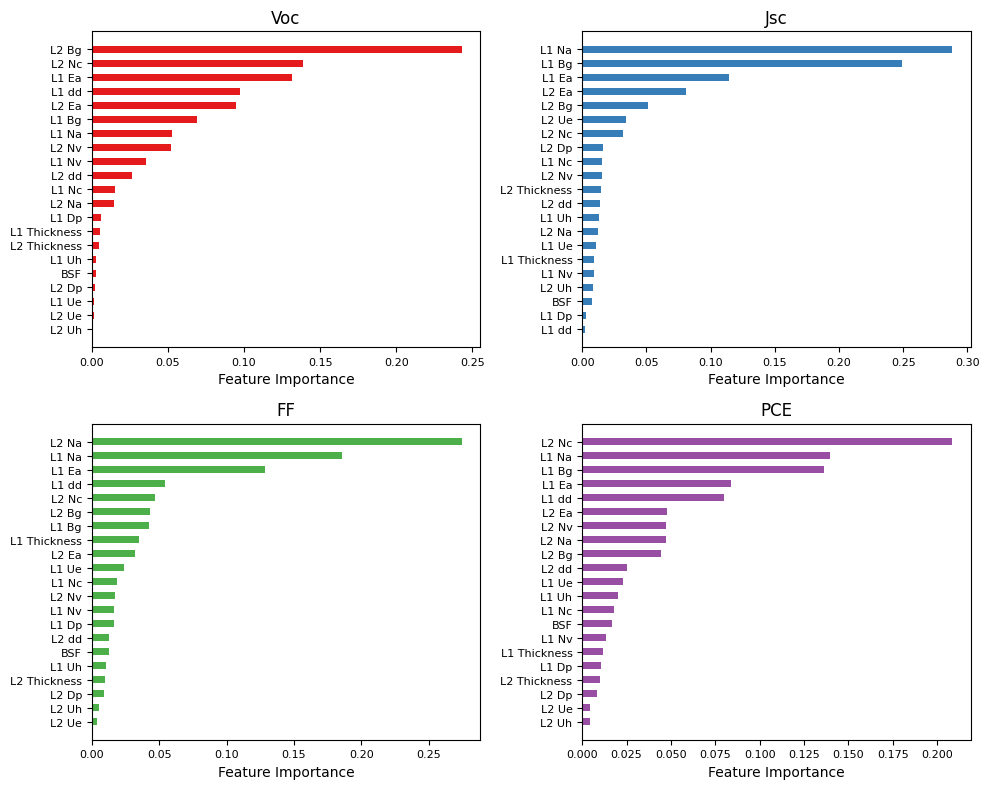

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from xgboost import XGBRegressor

# List of output variables
output_columns = ['Voc', 'Jsc', 'FF', 'PCE']

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()  # Flatten to easily iterate over axes

# Define a color palette from seaborn
colors = sns.color_palette("Set1", 4)

# Plotting feature importance for each output variable
for i, output in enumerate(output_columns):
    y_output = y_train[output]

    # Use simple XGBRegressor without hyperparameter tuning
    model = XGBRegressor(colsample_bytree= 1.0, learning_rate= 0.2, max_depth= 10, n_estimators= 200, subsample= 0.8, objective='reg:squarederror')
    model.fit(X_train, y_output)

    # Get feature importance for the current output
    feature_importance = model.feature_importances_

    # Sort the feature importances in descending order
    sorted_idx = np.argsort(feature_importance)[::1]  # descending order

    # Plotting the feature importance for the current output on the respective subplot
    axes[i].barh(X_train.columns[sorted_idx], feature_importance[sorted_idx], height=0.5, color=colors[i])
    axes[i].set_xlabel('Feature Importance')
    axes[i].set_title(f'{output}', size=12)
    axes[i].tick_params(axis='both', labelsize=8)
    axes[i].grid(False)

# Adjust layout
plt.tight_layout()
plt.show()


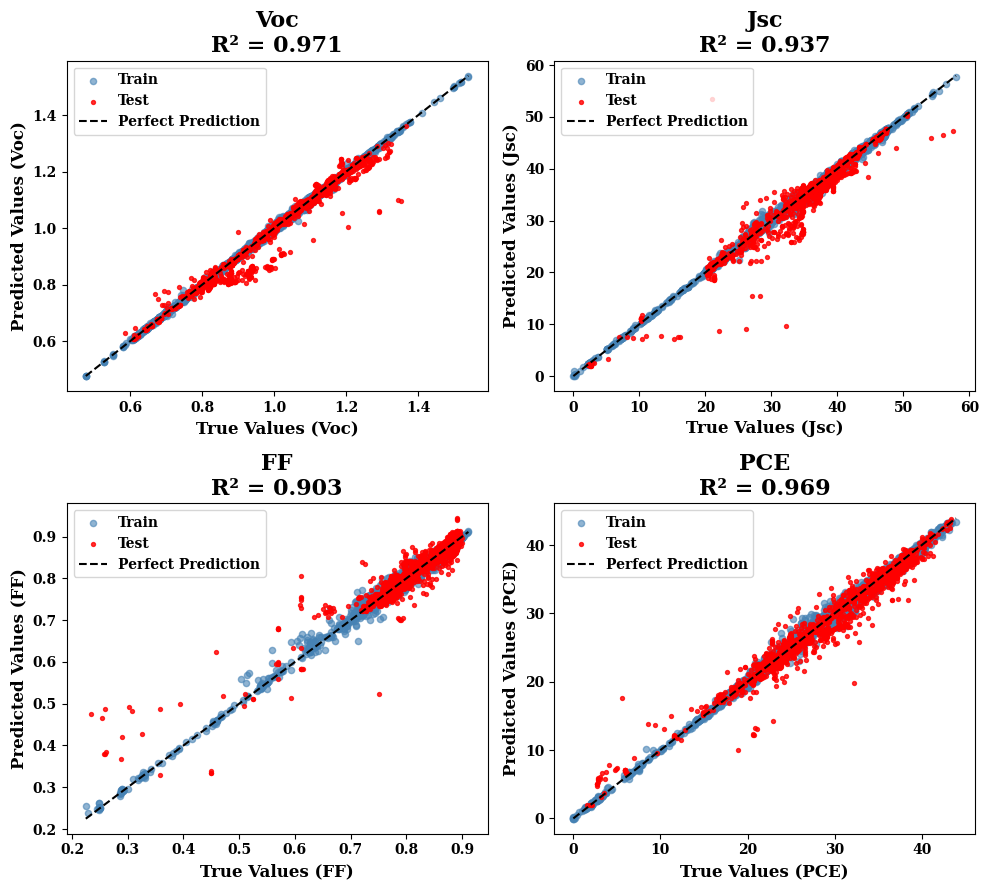

In [92]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import matplotlib as mpl

# --- Set global font to serif and bold ---
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.weight'] = 'bold'

# Define the columns for the plot
columns = ['Voc', 'Jsc', 'FF', 'PCE']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

# Loop through the columns and plot
for i, col in enumerate(columns):
    # Get the subplot position
    ax = axes[i // 2, i % 2]

    # Scatter plot for actual data and predictions
    ax.scatter(y_train[col], y_train_pred_df[col],
               color='steelblue', label='Train', alpha=0.6, s=20)
    ax.scatter(y_test[col], y_pred_XGB_df[col],
               color='red', label='Test', alpha=0.8, s=8)

    # Plot the line of perfect prediction (y = x)
    ax.plot([y_train[col].min(), y_train[col].max()],
            [y_train[col].min(), y_train[col].max()],
            'k--', label='Perfect Prediction')

    # Calculate R² for the test data
    r2_test = r2_score(y_test[col], y_pred_XGB_df[col])

    # Add title, labels, and legend
    ax.set_title(f'{col}\nR² = {r2_test:.3f}', size=16, weight='bold')
    ax.set_xlabel(f'True Values ({col})', size=12, weight='bold')
    ax.set_ylabel(f'Predicted Values ({col})', size=12, weight='bold')

    # Bold legend text
    leg = ax.legend()
    for text in leg.get_texts():
        text.set_fontweight('bold')

    # Make tick labels bold
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

    # Remove grid
    ax.grid(False)

# Adjust layout and save
plt.tight_layout()
plt.savefig('XGB_predicted_vs_actual_scatter.png', dpi=500, bbox_inches='tight')
plt.show()


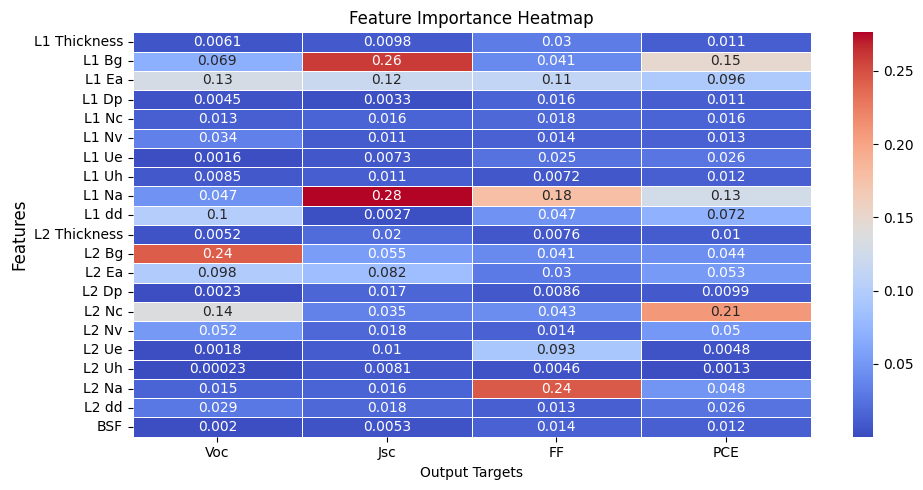

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from xgboost import XGBRegressor

# List of output variables
output_columns = ['Voc', 'Jsc', 'FF', 'PCE']

# Initialize an empty matrix to store feature importance for each output
feature_importance_matrix = np.zeros((X_train.shape[1], len(output_columns)))  # 10 features, 4 output targets

# Calculate feature importance for each output variable and store in the matrix
for i, output in enumerate(output_columns):
    y_output = y_train[output]  # Select the target variable

    # Initialize and train the XGBRegressor for the current output
    model = XGBRegressor(colsample_bytree= 1.0, learning_rate= 0.2, max_depth= 10, n_estimators= 200, subsample= 0.8, objective='reg:squarederror')
    model.fit(X_train, y_output)

    # Get feature importance for the current output
    feature_importance = model.feature_importances_

    # Store the feature importances in the matrix
    feature_importance_matrix[:, i] = feature_importance

# Create the heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(feature_importance_matrix, annot=True, cmap='coolwarm', xticklabels=output_columns,
            yticklabels=X_train.columns, cbar=True, linewidths=0.4)

# Add labels and title
plt.title('Feature Importance Heatmap', fontsize=12)
plt.xlabel('Output Targets', fontsize=10)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()


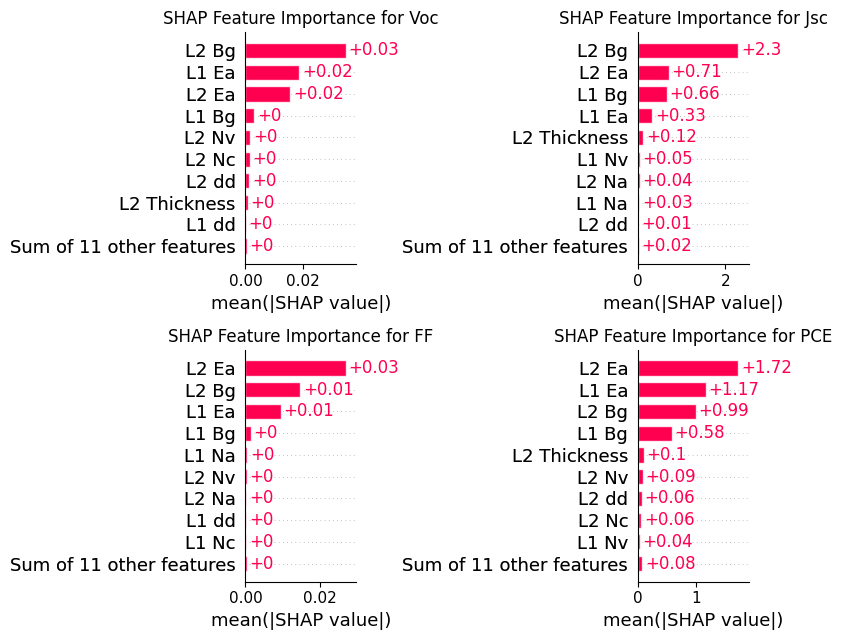

In [ ]:
import shap
import matplotlib.pyplot as plt
from sklearn.multioutput import MultiOutputRegressor

# Modern Set1 colormap access
set1 = plt.colormaps.get_cmap('Set1')

# Fit the multi-output XGBoost model
multi_output_model = MultiOutputRegressor(XGBRegressor(**grid_search.best_params_,
                                                       objective='reg:squarederror'))
multi_output_model.fit(X_train, y_train)

# Target names
target_names = ['Voc', 'Jsc', 'FF', 'PCE']

# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
axes = axes.flatten()

# Loop for SHAP values and bar plots
for i, target in enumerate(target_names):
    model = multi_output_model.estimators_[i]
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_test)

    # Use current axis
    plt.sca(axes[i])

    # Plot SHAP bar (color not customizable directly here)
    shap.plots.bar(shap_values, max_display=10, show=False)

    axes[i].set_title(f'SHAP Feature Importance for {target}', fontsize=12)

# Adjust and display
plt.tight_layout()
plt.show()
